In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc ,ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("E:/B-Tech/AI_ML/ASSIGNMENT/pbl_dataset.csv")
df.head()

,S NO.,Age,Gender,Income,Employment,LoanAmount,LoanTerm,InterestRate,CreditScore,DTI,PastDefaults,NumLoans,Savings,EMI,Default,Unnamed: 15
0,1,25,Male,300000,Salaried,100000,24,10.5,720,0.25,0,1,50000,4600,0,NaN
1,2,40,Female,800000,Self-employed,300000,36,12.2,680,0.35,1,2,150000,10000,0,NaN
2,3,35,Male,500000,Salaried,200000,48,11.0,590,0.45,2,3,80000,6000,1,NaN
3,4,29,Female,450000,Salaried,150000,36,9.5,710,0.28,0,1,60000,4800,0,NaN
4,5,50,Male,900000,Business,400000,60,13.5,550,0.50,3,4,200000,12000,1,NaN


In [4]:
df = df.drop(columns=['Unnamed: 15'],errors='ignore')

In [5]:
df['Employment']=df['Employment'].str.replace('-','')
df['Employment']=df['Employment'].str.strip()

In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Employment']=le.fit_transform(df['Employment'])

In [9]:
X = df.drop('Default' , axis=1)
y =df['Default']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [14]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [15]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance:")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [16]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 Logistic Regression Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.875
F1 Score: 0.9333333333333333

Confusion Matrix:
[[12  0]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



In [17]:
evaluate_model(y_test, y_pred_knn, "KNN")


🔹 KNN Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.875
F1 Score: 0.9333333333333333

Confusion Matrix:
[[12  0]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



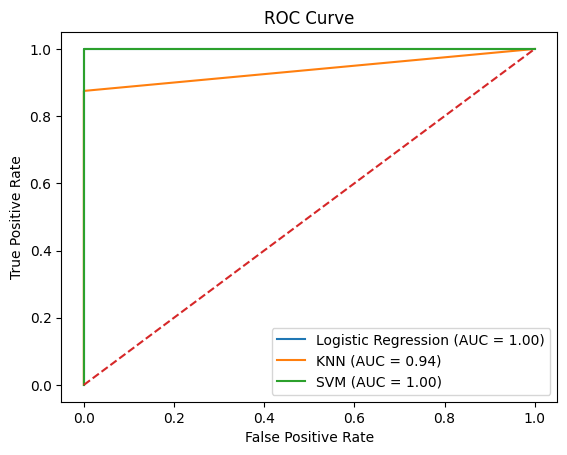

In [22]:
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, y_test, "Logistic Regression")
plot_roc(knn, X_test, y_test, "KNN")
plot_roc(svm, X_test, y_test, "SVM")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [40]:
def plot_confusion(model,X_test,y_test,title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test,y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("CONFUSION MATRIX")
    plt.show()

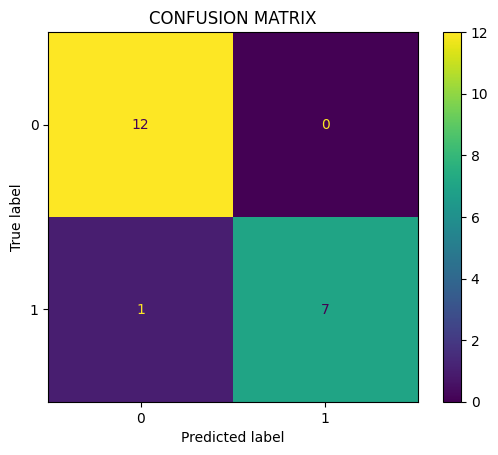

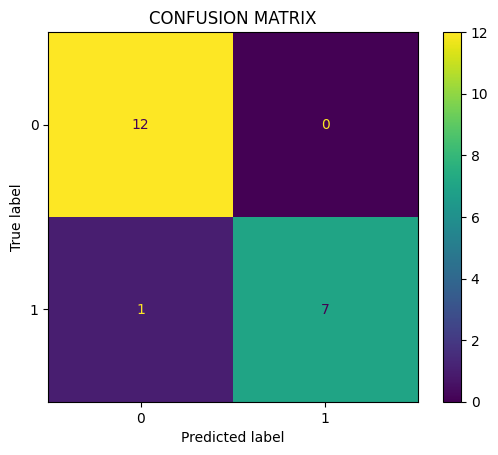

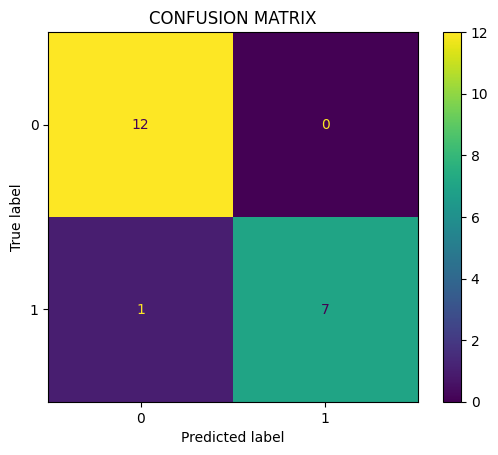

In [41]:
plot_confusion(lr, X_test, y_test, "Logistic Regression")
plot_confusion(knn, X_test, y_test, "KNN")
plot_confusion(svm, X_test, y_test, "SVM")

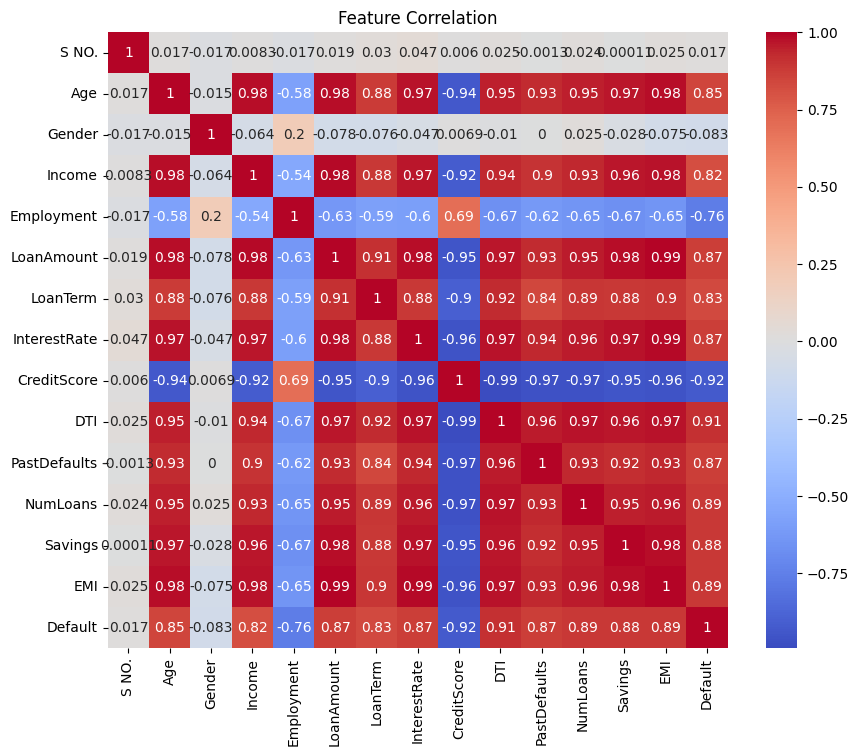

In [42]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Testing is done, predicted for loan default prediction system, model achieved overall accuracy of 95.0%, confusion matrix and classification reports are also included